In [53]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [2]:
X,y=make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [4]:
df=pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target']=y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.025010,0.252791,0.385681,-1.050048,0.855826,0
1,0.243773,-2.527443,1.749435,-0.611875,-3.040147,0
2,3.838214,-4.096424,-1.690982,-1.985909,0.027517,0
3,1.492173,-1.142862,0.008670,-1.170859,0.069709,0
4,-0.922134,-1.532897,1.704410,1.354941,-2.054423,1


In [5]:
#function for row sampling
def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [64]:
#function for feature sampling
def sample_features(df,percent):
    cols=random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
    new_df=df[cols]
    new_df['target']=df['target']
    return new_df

In [96]:
#function for combined sampling
def combined_sampling(df,row_percent,col_percent):
    new_df=sample_rows(df,row_percent)
    return sample_features(new_df,col_percent)

In [66]:
df1= sample_rows(df,0.2)

In [67]:
df2=sample_rows(df,0.2)

In [68]:
df3= sample_rows(df,0.2)

In [69]:
df1.shape

(20, 6)

In [70]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [71]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [72]:
from sklearn.tree import plot_tree

[Text(0.6, 0.875, 'x[2] <= 2.016\ngini = 0.42\nsamples = 20\nvalue = [6, 14]'),
 Text(0.4, 0.625, 'x[1] <= -0.836\ngini = 0.219\nsamples = 16\nvalue = [2, 14]'),
 Text(0.5, 0.75, 'True  '),
 Text(0.2, 0.375, 'gini = 0.0\nsamples = 12\nvalue = [0, 12]'),
 Text(0.6, 0.375, 'x[3] <= 0.821\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.4, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.8, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.625, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.7, 0.75, '  False')]

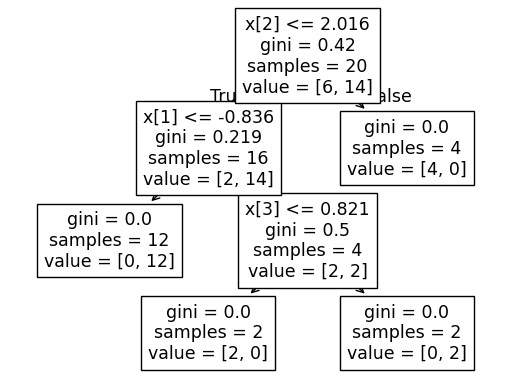

In [73]:
plot_tree(clf1)

[Text(0.6, 0.875, 'x[0] <= 0.684\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.4, 0.625, 'x[4] <= -2.192\ngini = 0.355\nsamples = 13\nvalue = [3, 10]'),
 Text(0.5, 0.75, 'True  '),
 Text(0.2, 0.375, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.6, 0.375, 'x[3] <= -1.285\ngini = 0.165\nsamples = 11\nvalue = [1, 10]'),
 Text(0.4, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.125, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.8, 0.625, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.7, 0.75, '  False')]

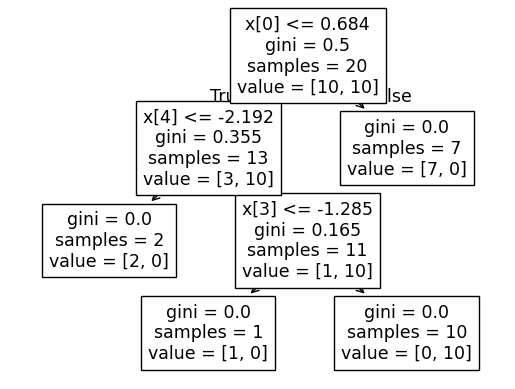

In [74]:
plot_tree(clf2)

[Text(0.7142857142857143, 0.9, 'x[0] <= 0.18\ngini = 0.495\nsamples = 20\nvalue = [11, 9]'),
 Text(0.5714285714285714, 0.7, 'x[1] <= 0.768\ngini = 0.298\nsamples = 11\nvalue = [2, 9]'),
 Text(0.6428571428571428, 0.8, 'True  '),
 Text(0.42857142857142855, 0.5, 'x[2] <= 0.439\ngini = 0.18\nsamples = 10\nvalue = [1, 9]'),
 Text(0.2857142857142857, 0.3, 'x[1] <= -0.794\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.14285714285714285, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.42857142857142855, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5714285714285714, 0.3, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.7142857142857143, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8571428571428571, 0.7, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.7857142857142857, 0.8, '  False')]

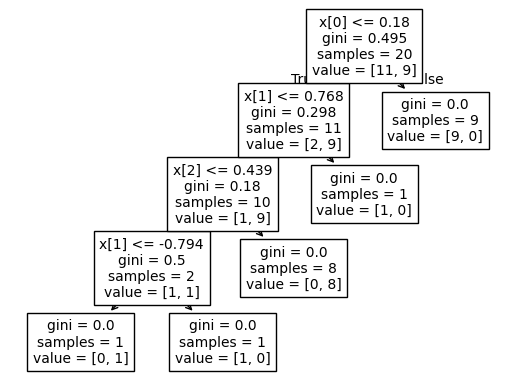

In [75]:
plot_tree(clf3)

In [76]:
clf1.predict(np.array([0.025010	,0.252791,0.385681,-1.050048,0.855826]).reshape(1,5))

C:\Users\USER\anaconda3\envs\Booksenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [77]:
clf2.predict(np.array([0.025010	,0.252791,0.385681,-1.050048,0.855826]).reshape(1,5))

C:\Users\USER\anaconda3\envs\Booksenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [78]:
clf3.predict(np.array([0.025010	,0.252791,0.385681,-1.050048,0.855826]).reshape(1,5))

C:\Users\USER\anaconda3\envs\Booksenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [79]:
df1=sample_features(df,0.8)

C:\Users\USER\AppData\Local\Temp\ipykernel_13376\3932070712.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']


In [80]:
df2=sample_features(df,0.8)

C:\Users\USER\AppData\Local\Temp\ipykernel_13376\3932070712.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']


In [81]:
df3=sample_features(df,0.8)

C:\Users\USER\AppData\Local\Temp\ipykernel_13376\3932070712.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']


In [82]:
df1.shape

(100, 5)

In [84]:
clf1.fit(df1.iloc[:,0:4],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:4],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:4],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [85]:
    df3                                                     

,col2,col3,col4,col1,target
0,0.252791,0.385681,-1.050048,0.025010,0
1,-2.527443,1.749435,-0.611875,0.243773,0
2,-4.096424,-1.690982,-1.985909,3.838214,0
3,-1.142862,0.008670,-1.170859,1.492173,0
4,-1.532897,1.704410,1.354941,-0.922134,1
...,...,...,...,...,...
95,-1.730607,1.288778,1.567599,-2.108880,1
96,-1.182661,0.772465,-1.070587,2.318252,0
97,-1.062114,1.090302,-2.110736,1.754425,0
98,-2.849311,-0.339800,-1.368057,2.472164,0


In [86]:
clf1.predict(np.array([-1.062114,1.090302,-2.110736,1.754425]).reshape(1,4))

C:\Users\USER\anaconda3\envs\Booksenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [87]:
clf2.predict(np.array([-1.062114,1.090302,-2.110736,1.754425]).reshape(1,4))

C:\Users\USER\anaconda3\envs\Booksenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [88]:
clf3.predict(np.array([-1.062114,1.090302,-2.110736,1.754425]).reshape(1,4))

C:\Users\USER\anaconda3\envs\Booksenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [97]:
df1=combined_sampling(df,0.5,0.5)

C:\Users\USER\AppData\Local\Temp\ipykernel_13376\3932070712.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']


In [99]:
df2=combined_sampling(df,0.5,0.5)

C:\Users\USER\AppData\Local\Temp\ipykernel_13376\3932070712.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']


In [100]:
df3=combined_sampling(df,0.5,0.5)

C:\Users\USER\AppData\Local\Temp\ipykernel_13376\3932070712.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target']=df['target']


In [101]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [104]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.7333333333333333, 0.9375, 'x[0] <= -0.046\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.6, 0.8125, 'x[1] <= -0.538\ngini = 0.358\nsamples = 30\nvalue = [23, 7]'),
 Text(0.6666666666666666, 0.875, 'True  '),
 Text(0.5333333333333333, 0.6875, 'x[0] <= -0.651\ngini = 0.475\nsamples = 18\nvalue = [11, 7]'),
 Text(0.4, 0.5625, 'x[1] <= -1.865\ngini = 0.408\nsamples = 14\nvalue = [10, 4]'),
 Text(0.3333333333333333, 0.4375, 'x[1] <= -1.92\ngini = 0.494\nsamples = 9\nvalue = [5, 4]'),
 Text(0.26666666666666666, 0.3125, 'x[0] <= -1.112\ngini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.13333333333333333, 0.1875, 'x[1] <= -2.917\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.06666666666666667, 0.0625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2, 0.0625, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.4, 0.1875, 'x[1] <= -2.789\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.3333333333333333, 0.0625, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Tex

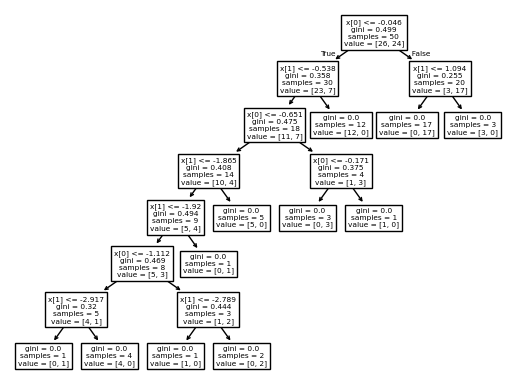

In [105]:
plot_tree(clf3)

[Text(0.5454545454545454, 0.95, 'x[1] <= 0.244\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.45454545454545453, 0.85, 'x[0] <= -2.108\ngini = 0.487\nsamples = 43\nvalue = [25, 18]'),
 Text(0.5, 0.8999999999999999, 'True  '),
 Text(0.2727272727272727, 0.75, 'x[0] <= -2.739\ngini = 0.426\nsamples = 13\nvalue = [4, 9]'),
 Text(0.18181818181818182, 0.65, 'x[1] <= -1.443\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.09090909090909091, 0.55, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.2727272727272727, 0.55, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.36363636363636365, 0.65, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.6363636363636364, 0.75, 'x[1] <= -1.028\ngini = 0.42\nsamples = 30\nvalue = [21, 9]'),
 Text(0.5454545454545454, 0.65, 'x[1] <= -4.232\ngini = 0.495\nsamples = 20\nvalue = [11, 9]'),
 Text(0.45454545454545453, 0.55, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6363636363636364, 0.55, 'x[0] <= 1.079\ngini = 0.498\nsamples = 17\nva

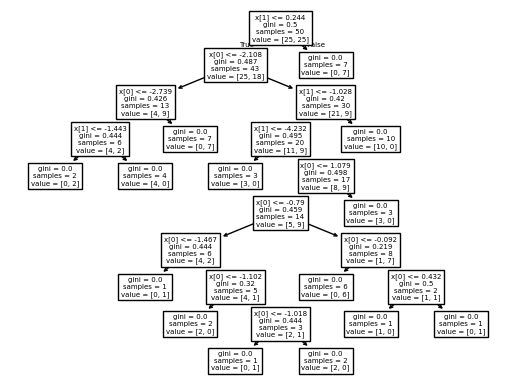

In [106]:
plot_tree(clf1)

In [107]:
df3

,col4,col2,target
13,-1.155858,-2.107255,0
50,2.498278,0.914889,1
56,-0.564155,-1.546415,1
22,3.581429,-1.052474,1
32,-1.068344,-2.492199,1
46,1.108203,-2.628763,1
84,-1.009172,0.305165,0
53,0.875900,-0.967128,1
47,0.353909,-2.100265,1
64,-2.294247,-2.984658,1


In [108]:
clf1.predict(np.array([-1.068344,-2.492199]).reshape(1,2))

C:\Users\USER\anaconda3\envs\Booksenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [109]:
clf2.predict(np.array([-1.068344,-2.492199]).reshape(1,2))

C:\Users\USER\anaconda3\envs\Booksenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [110]:
clf3.predict(np.array([-1.068344,-2.492199]).reshape(1,2))

C:\Users\USER\anaconda3\envs\Booksenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])